<a href="https://colab.research.google.com/github/Olivier812/Computational-methods-for-multi-modal-data-analysis-assignment/blob/main/Assignment_PartB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IIDS67692 Computational Techniques for Multi-modal Data
##Assignment Part-B: Multimodal Fusion and LoRA Adaptation for Heath Decision Support



In [1]:
!nvidia-smi

Mon Jun  1 03:08:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

###Installing required python packages

In [2]:
!pip install -q datasets evaluate bert_score rouge_score torch torchvision transformers peft gdown --upgrade pip --upgrade torchao

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 13.7 MB/s eta 0:00:00
   ━━━━━━

In [11]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


#Dataset

Huggingface Link: https://huggingface.co/datasets/flaviagiammarino/path-vqa

The PathVQA Dataset is available on Hugging Face and contains 19,654 training, 6,259 validation, and 6,719 test question-answer pairs across approximately 5,004 pathology images.

The PathVQA Dataset is a large-scale medical visual question answering benchmark designed for pathology image understanding. It contains more than 32,000 question-answer pairs associated with pathology images collected from publicly available medical sources. The dataset supports multimodal AI research by combining visual pathology information with natural language reasoning tasks, enabling models to answer clinically relevant questions about tissue appearance, disease characteristics, and diagnostic findings. PathVQA has become a widely used benchmark for evaluating medical VQA systems and multimodal large language models in digital pathology research.

[1] He, Xuehai, et al. "Towards visual question answering on pathology images." Proceedings of the 59th Annual Meeting of the Association for Computational Linguistics and the 11th International Joint Conference on Natural Language Processing (Volume 2: Short Papers). 2021.

[2] He, Xuehai, et al. "Pathvqa: 30000+ questions for medical visual question answering." arXiv preprint arXiv:2003.10286 (2020).

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/validation-00000-of-00003-90a5518d2(…):   0%|          | 0.00/41.3M [00:00<?, ?B/s]

data/validation-00001-of-00003-cbfe947a3(…):   0%|          | 0.00/45.7M [00:00<?, ?B/s]

data/validation-00002-of-00003-9ec816895(…):   0%|          | 0.00/64.7M [00:00<?, ?B/s]

Generating validation split: 0 examples [00:00, ? examples/s]

samplesize: 6259
dict_keys(['image', 'question', 'answer'])
image reso;ution: (205, 315, 4)


Text(0.5, 1.0, 'Q: what is acute viral hepatitis characterized by?\nA: predominantly lymphocytic infiltrate')

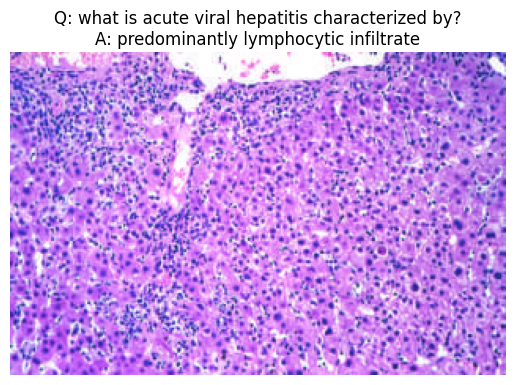

In [3]:
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
plt.axis('off')

pathvqa_valid = load_dataset("parquet", data_files={"validation": "hf://datasets/flaviagiammarino/path-vqa/data/validation-*.parquet"}, split="validation")
print('samplesize:', len(pathvqa_valid))
idx=3
print(pathvqa_valid[idx].keys())
print('image reso;ution:', np.array(pathvqa_valid[idx]['image']).shape)
plt.imshow(pathvqa_valid[idx]['image'])
plt.title(f'Q: {pathvqa_valid[idx]['question']}\nA: {pathvqa_valid[idx]['answer']}', fontsize=12)


#Prepare Dataloader

In [4]:
!pip install -U sympy torchvision torch

split: train = 2400 and test=600
Sample size: Training: 2400 validation: 600
image resolution: torch.Size([3, 224, 224])


Text(0.5, 1.0, 'Q: is gross islands of tumor?\nA: yes')

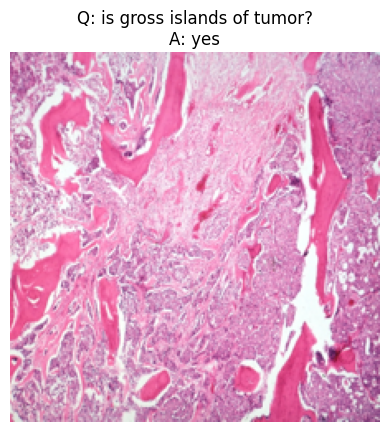

In [5]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader


class PathVQADataset(Dataset):
    def __init__(self, hf_dataset):
        """
        hf_dataset: HuggingFace dataset (already loaded split)
        """

        self.dataset = hf_dataset

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        # --- Image ---
        # HF dataset already provides PIL image
        raw_image = sample["image"].convert('RGB')
        img = self.transform(raw_image)

        # --- Question & Answer ---
        question = sample["question"]
        answer = sample["answer"]

        return img, question, answer

subset = pathvqa_valid.shuffle(seed=42).select(range(3000))
split_dataset = subset.train_test_split(test_size=0.2, seed=42)

# split_dataset = pathvqa_valid.train_test_split(test_size=0.2, seed=42)

train_data = split_dataset["train"]
val_data   = split_dataset["test"]
print(f'split: train = {len(train_data)} and test={len(val_data)}')

train_dataset = PathVQADataset(train_data)
val_dataset   = PathVQADataset(val_data)
print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)


img, question, answer = train_dataset[1]
print('image resolution:', img.size())
plt.axis('OFF')
plt.imshow(img.permute(1,2,0))
plt.title(f'Q: {question}\nA: {answer}', fontsize=12)

#Model Architecture

Paper: https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

GPT-2 uses a decoder-only transformer architecture with multiple model sizes; the commonly used GPT-2 Base model contains 12 transformer blocks (layers), a context window of 1024 tokens, a hidden embedding size of 768, and about 117 million parameters, while larger variants scale up to 48 transformer blocks and 1.5 billion parameters.

[1] Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language models are unsupervised multitask learners. OpenAI blog, 1(8), 9.

###Cross-Attention Fusion

In [6]:
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

####Cross-Attention Fusion###########
class CrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=8, dropout=0.1):
        super().__init__()

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, text_embeds, image_embeds, text_att_mask=None):
        """
        text_embeds:  [B, T, 768]
        image_embeds: [B, N, 768]
        text attends to image
        """

        attended_text, attn_weights = self.cross_attn(
            query=text_embeds,
            key=image_embeds,
            value=image_embeds,
            need_weights=False
        )

        x = self.norm1(text_embeds + attended_text)
        x = self.norm2(x + self.ffn(x))

        return x

W0601 03:12:36.695000 1406 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0601 03:12:36.762000 1406 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


###Gated Cross-Attention Fusion

In [22]:
#Write your code for Gated-Cross Attention Fusion
class GatedCrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=4, dropout=0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(hidden_dim)
    def forward(self, text_embeds, image_embeds, text_att_mask=None):
        attended_visual, _ = self.cross_attn(
            query=text_embeds,
            key=image_embeds,
            value=image_embeds,
            need_weights=False
        )
        gate_value = self.gate(
            torch.cat([text_embeds, attended_visual], dim=-1)
        )
        fused = gate_value * attended_visual + (1 - gate_value) * text_embeds
        fused = self.norm(fused)

        return fused

###MedVQA model (Mulitmodal GPT2)

In [8]:
#CrossAttentionFusion
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class MedVQA(nn.Module):
    def __init__(self, peft_config=None):
        super(MedVQA, self).__init__()

        # visual encoder
        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(model_name)

        # Freeze all parameters in visual encoder
        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        # tokenizer
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token  # end of string

        # gpt2 decoder
        gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt = get_peft_model(gpt, peft_config)
        # self.gpt.print_trainable_parameters()  # Verify trainable LoRA parameters
        self.fusion = CrossAttentionFusion(
            hidden_dim=768,
            num_heads=4
        )

    def forward(self, image, qa_inputs_ids, qa_att_mask):
        image_embeds = self.visual_encoder(image).last_hidden_state
        # [B, 197, 768]

        text_embeds = self.gpt.get_input_embeddings()(qa_inputs_ids)
        # [B, T, 768]

        fused_embeds = self.fusion(
            text_embeds=text_embeds,
            image_embeds=image_embeds,
            text_att_mask=qa_att_mask
        )
        # [B, T, 768]

        gpt_output = self.gpt(
            inputs_embeds=fused_embeds,
            attention_mask=qa_att_mask
        )
        return gpt_output.logits

In [23]:
#GatedCrossAttentionFusion
class MedVQA(nn.Module):
    def __init__(self, peft_config=None):
        super(MedVQA, self).__init__()

        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(model_name)

        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token

        gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt = get_peft_model(gpt, peft_config)

        self.fusion = GatedCrossAttentionFusion(
            hidden_dim=768,
            num_heads=4
        )

    def forward(self, image, qa_inputs_ids, qa_att_mask):
        image_embeds = self.visual_encoder(image).last_hidden_state
        text_embeds = self.gpt.get_input_embeddings()(qa_inputs_ids)

        fused_embeds = self.fusion(
            text_embeds=text_embeds,
            image_embeds=image_embeds,
            text_att_mask=qa_att_mask
        )

        gpt_output = self.gpt(
            inputs_embeds=fused_embeds,
            attention_mask=qa_att_mask
        )

        return gpt_output.logits

#Model Training

In [27]:
#num_epochs = 1 后改为2再次训练得到第三组结果
from peft import LoraConfig, TaskType
from tqdm import tqdm
import torch.nn.functional as F

peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["c_attn", "c_proj"]
)

model = MedVQA(peft_config=peft_config).to(device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

num_epochs = 2
max_batches = 100

model.train()

for epoch in range(num_epochs):
    total_loss = 0

    for step, batch in enumerate(tqdm(train_loader)):
        if step >= max_batches:
            break

        images = batch[0].to(device)
        questions = list(batch[1])
        answers = list(batch[2])

        qa_texts = [
            f"Question: {q} Answer: {a}"
            for q, a in zip(questions, answers)
        ]

        encoded = model.tokenizer(
            qa_texts,
            padding=True,
            truncation=True,
            max_length=64,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        logits = model(images, input_ids, attention_mask)

        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = input_ids[:, 1:].contiguous()

        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            ignore_index=model.tokenizer.pad_token_id
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, average loss: {total_loss / (step+1):.4f}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

100%|██████████| 75/75 [01:27<00:00,  1.17s/it]


Epoch 1, average loss: 4.8765


100%|██████████| 75/75 [01:26<00:00,  1.15s/it]

Epoch 2, average loss: 3.2644


#Inference: few samples (prediction visualisations)

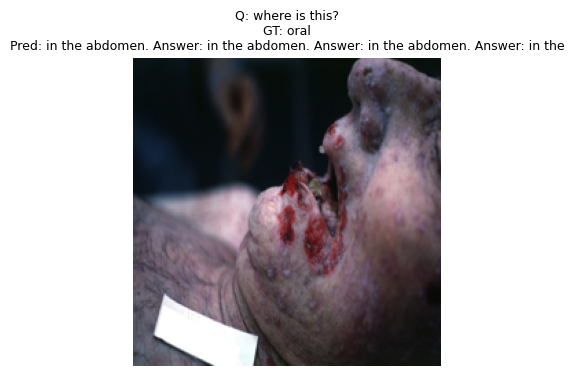

Question: where is this?
Ground truth: oral
Prediction: in the abdomen. Answer: in the abdomen. Answer: in the abdomen. Answer: in the
--------------------------------------------------


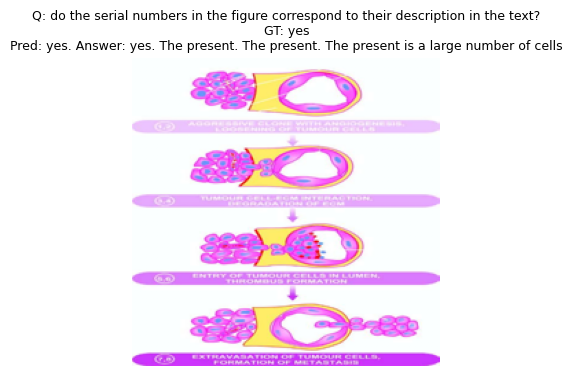

Question: do the serial numbers in the figure correspond to their description in the text?
Ground truth: yes
Prediction: yes. Answer: yes. The present. The present. The present is a large number of cells
--------------------------------------------------


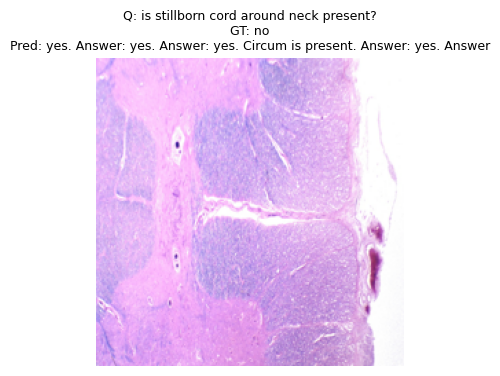

Question: is stillborn cord around neck present?
Ground truth: no
Prediction: yes. Answer: yes. Answer: yes. Circum is present. Answer: yes. Answer
--------------------------------------------------


In [28]:
#run inference to collect the prediction visualisations
import matplotlib.pyplot as plt

model.eval()

def predict_answer(model, image, question, max_new_tokens=20):
    image = image.unsqueeze(0).to(device)

    prompt = f"Question: {question} Answer:"
    encoded = model.tokenizer(
        [prompt],
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    generated_ids = input_ids.clone()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(image, generated_ids, attention_mask)
            next_token_logits = logits[:, -1, :]
            next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)

            generated_ids = torch.cat([generated_ids, next_token], dim=1)
            attention_mask = torch.cat(
                [attention_mask, torch.ones_like(next_token).to(device)],
                dim=1
            )

            if next_token.item() == model.tokenizer.eos_token_id:
                break

    decoded = model.tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    return decoded.replace(prompt, "").strip()


sample_indices = [0, 1, 2]

for idx in sample_indices:
    image, question, answer = val_dataset[idx]
    pred = predict_answer(model, image, question)

    plt.figure(figsize=(4, 4))
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")
    plt.title(
        f"Q: {question}\nGT: {answer}\nPred: {pred}",
        fontsize=9
    )
    plt.show()

    print("Question:", question)
    print("Ground truth:", answer)
    print("Prediction:", pred)
    print("-" * 50)

#Inference: (Evaluation Metrics)

In [29]:
#run inference to collect the evaluation metrics (BLEU, ROUGE-L, and METEOR)
from tqdm import tqdm
import evaluate

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")

predictions = []
references = []

model.eval()

for i in tqdm(range(min(100, len(val_dataset)))):

    image, question, answer = val_dataset[i]

    pred = predict_answer(
        model,
        image,
        question
    )

    predictions.append(pred)
    references.append(answer)

bleu = bleu_metric.compute(
    predictions=predictions,
    references=[[r] for r in references]
)

rouge = rouge_metric.compute(
    predictions=predictions,
    references=references
)

meteor = meteor_metric.compute(
    predictions=predictions,
    references=references
)

print("BLEU:", bleu["bleu"])
print("ROUGE-L:", rouge["rougeL"])
print("METEOR:", meteor["meteor"])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
100%|██████████| 100/100 [01:05<00:00,  1.53it/s]


BLEU: 0.0
ROUGE-L: 0.07070110445110447
METEOR: 0.07465904298111116
